<a href="https://colab.research.google.com/github/arushnab/MedLit/blob/main/medlit_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

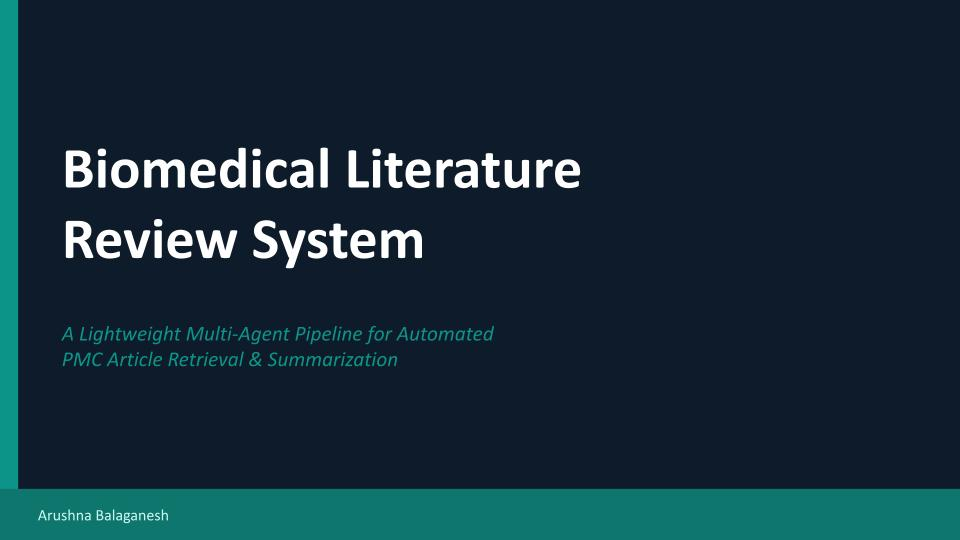

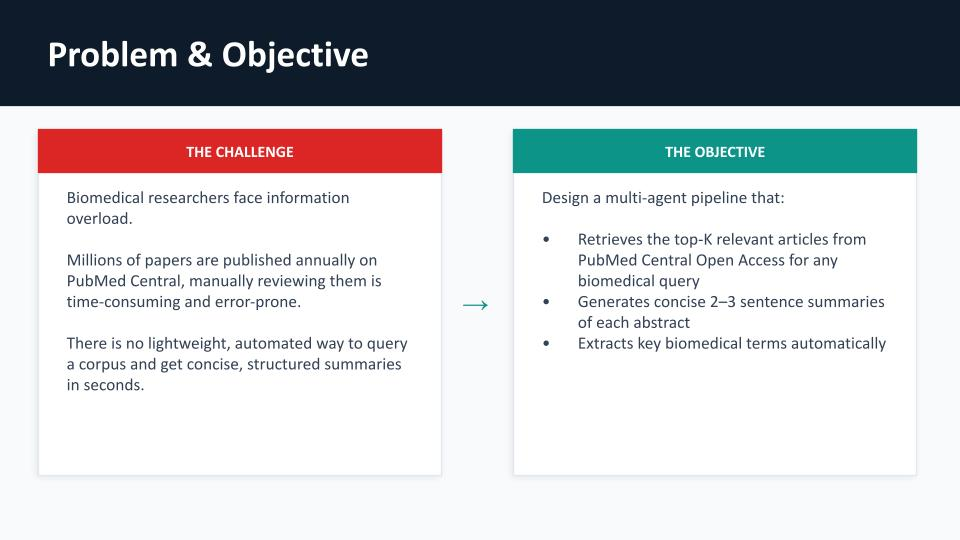

##Section 1: Setup & Data Access

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import nbformat

path = "/content/drive/MyDrive/Colab Notebooks/medlit_pipeline.ipynb"
nb = nbformat.read(path, as_version=4)

if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(nb, path)

Mounted at /content/drive


In [1]:
# Install AWS SDK (boto3) to access PMC articles stored on S3
# Install pandas to load and filter the article metadata CSV
!pip install boto3 pandas --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.7 MB/s eta 0:00:00


In [2]:
# Imports
import boto3                          # AWS SDK — connects to S3
import pandas as pd                   # table/dataframe library
import xml.etree.ElementTree as ET    # parses PMC article XML files
import re                             # regex — used to clean whitespace
from io import StringIO               # treats strings as file objects
from botocore import UNSIGNED
from botocore.config import Config    # needed for public (unsigned) S3 access
from typing import List, Dict, Optional

# S3 Configurations
S3_BUCKET = "pmc-oa-opendata"         # public PMC bucket on AWS
S3_REGION = "us-east-1"
METADATA_KEY = "oa_comm/txt/metadata/csv/oa_comm.filelist.csv"

# Connect to S3 without credentials
s3_client = boto3.client(
    "s3",
    region_name=S3_REGION,
    config=Config(signature_version=UNSIGNED)
)

In [3]:
# Download the article index CSV from S3 - essentially a catalogue of 4.8 million articles
response = s3_client.get_object(Bucket=S3_BUCKET, Key=METADATA_KEY)
csv_content = response['Body'].read().decode('utf-8')
df = pd.read_csv(StringIO(csv_content))

# Filter out old articles
df = df[~df['Article Citation'].str.contains('18[0-9][0-9]', na=False)]
print(f"{len(df):,} modern articles available")

4,870,019 modern articles available


In [4]:
# Download a single article's XML from S3 by its accession ID
# Returns the raw XML string, or None if the article is missing/inaccessible
def fetch_article_xml(accession_id: str) -> Optional[str]:
    key = f"oa_comm/xml/all/{accession_id}.xml"   # S3 path to the article
    try:
        response = s3_client.get_object(Bucket=S3_BUCKET, Key=key)
        return response['Body'].read().decode('utf-8')
    except Exception:
        return None  # skip missing articles

# Parse the XML and extract abstract, title, and journal
def extract_fields_from_xml(xml_text: str) -> Dict:
    if not xml_text:
        return {}
    try:
        root = ET.fromstring(xml_text) # parses the XML into a navigable tree structure

        #String manipulation to find abstract, title, and journal tag values
        abstract_el = root.find('.//abstract')
        abstract = ' '.join(abstract_el.itertext()).strip() if abstract_el is not None else ""
        abstract = re.sub(r'\s+', ' ', abstract)[:1500]

        title_el = root.find('.//article-title')
        title = ' '.join(title_el.itertext()).strip() if title_el is not None else "Unknown Title"

        journal_el = root.find('.//journal-title')
        journal = journal_el.text.strip() if journal_el is not None else "Unknown Journal"

        return {'abstract': abstract, 'title': title, 'journal': journal}

    except ET.ParseError:
        return {}

In [5]:
articles = []
failed = 0

# Filter articles by biomedical keywords in the citation
# This scopes the corpus to Sanofi-relevant areas but introduces bias
# Articles using different terminology may be missed
mask = (
    df['Article Citation'].str.contains('vaccine|immunol|pediatr', case=False, na=False) |
    df['Article Citation'].str.contains('oncol|cancer|tumor', case=False, na=False) |
    df['Article Citation'].str.contains('protein|bioinformat|comput biol', case=False, na=False)
)
filtered_df = df[mask]

# Sample 300 candidates, aim for 100 viable ones, buffer for missing/short abstracts
# random_state=42 makes the sample reproducible across runs
sample = filtered_df.sample(n=min(300, len(filtered_df)), random_state=42)

for _, row in sample.iterrows():
    if len(articles) >= 100:
        break

    accession_id = str(row['AccessionID'])
    pmid = str(row.get('PMID', 'Unknown'))

    xml_text = fetch_article_xml(accession_id) # used to build the S3 file path
    fields = extract_fields_from_xml(xml_text) if xml_text else {}
    abstract = fields.get('abstract', '')

    # Only keep articles with a meaningful abstract (> 100 chars)
    if len(abstract) > 100:
        articles.append({
            'pmid': pmid,
            'accession_id': accession_id,
            'title': fields.get('title', 'Unknown'),
            'abstract': abstract,
            'journal': fields.get('journal', 'Unknown')
        })
    else:
        failed += 1  # count skipped articles for transparency

print(f"Got {len(articles)} articles ({failed} skipped)")
print(f"\nExample:")
print(f"  Title: {articles[0]['title']}")
print(f"  Abstract: {articles[0]['abstract'][:200]}")

Got 100 articles (3 skipped)

Example:
  Title: Meningococcal carriage and disease—Population biology and evolution
  Abstract: Meningococcal disease occurs worldwide with incidence rates varying from 1 to 1000 cases per 100,000. The causative organism, Neisseria meningitidis , is an obligate commensal of humans, which normall


In [6]:
import json

# Save articles to disk so we don't have to re-fetch from S3 every time
with open('articles.json', 'w') as f:
    json.dump(articles, f, indent=2)

print(f"Saved {len(articles)} articles to articles.json")

Saved 100 articles to articles.json


In [7]:
# Load articles from disk instead of re-fetching from S3
# Run this cell at teh start of session if articles.json already exists
with open('articles.json', 'r') as f:
    articles = json.load(f)

print(f"Loaded {len(articles)} articles")
print(f"Keys in each article: {list(articles[0].keys())}")

Loaded 100 articles
Keys in each article: ['pmid', 'accession_id', 'title', 'abstract', 'journal']


##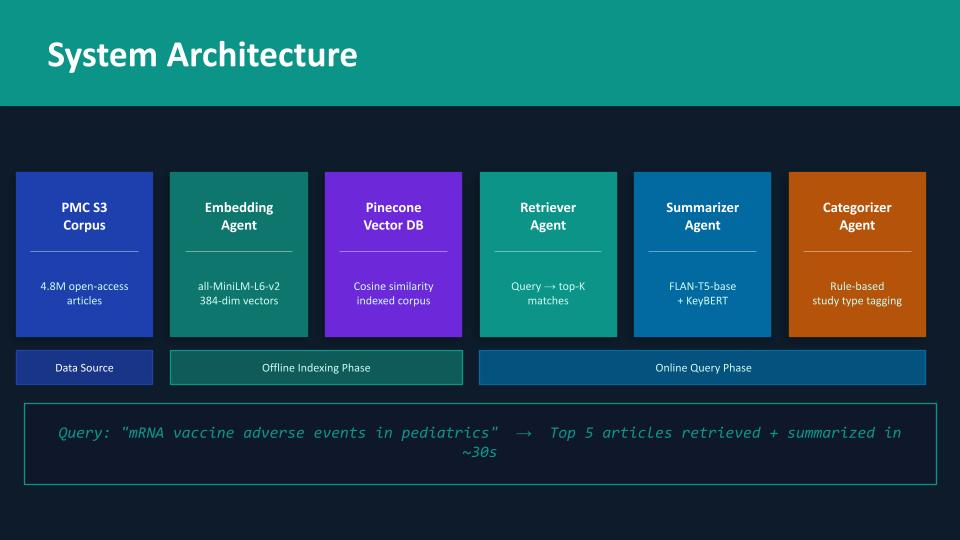

##Section 2: Retriever Agent


In [8]:
# Install sentence-transformers to simplify generating text embeddings and
# pinecone for vector database to store and search embeddings
!pip install sentence-transformers pinecone --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 742.7/742.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.7/280.7 kB 26.3 MB/s eta 0:00:00


In [9]:
from pinecone import Pinecone
from google.colab import userdata
userdata.get('PINECONE_API_KEY')
from sentence_transformers import SentenceTransformer

# Connect to Pinecone account using API key
api_key = userdata.get('PINECONE_API_KEY')
pc = Pinecone(api_key=api_key)

# Retreive index for task
index = pc.Index("pmc-articles")

print("Connected to Pinecone")
#Check size of vector db
print(f"Index stats: {index.describe_index_stats()}")

Connected to Pinecone
Index stats: {'_response_info': {'raw_headers': {'connection': 'keep-alive',
                                    'content-length': '185',
                                    'content-type': 'application/json',
                                    'date': 'Mon, 30 Mar 2026 18:47:22 GMT',
                                    'grpc-status': '0',
                                    'server': 'envoy',
                                    'x-envoy-upstream-service-time': '99',
                                    'x-pinecone-request-latency-ms': '98',
                                    'x-pinecone-response-duration-ms': '101'}},
 'dimension': 384,
 'index_fullness': 0.0,
 'memoryFullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'__default__': {'vector_count': 397}},
 'storageFullness': 0.0,
 'total_vector_count': 397,
 'vector_type': 'dense'}


In [10]:
#Load the embedding model
# all-MiniLM-L6-v2 is small, fast, and has strong general performance
# Produces 384-dimensional vectors
# Note: this same model must be used at query time
print("Loading embedding model")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded")

Loading embedding model


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded


In [11]:
# We combine the tile + abstract for richer signal
texts = [f"{a['title']}. {a['abstract']}" for a in articles]

print(f"Embedding {len(texts)} articles...")

# Runs all 100 articles through the model, encodes each as 384 numbers
embeddings = model.encode(texts, normalize_embeddings=True, show_progress_bar=True)
print(f"Embeddings shape: {embeddings.shape}")  # should be (100, 384)

# Upload to Pinecone
# Pinecone expects a list of (id, vector, metadata) tuples
print(" Uploading to Pinecone")

vectors = []

for i, article in enumerate(articles):
    vectors.append({
        "id": article['accession_id'],        # unique ID for each article
        "values": embeddings[i].tolist(),      # the 384-dimensional vector
        "metadata": {                          # extra info stored alongside vector
            "pmid": article['pmid'],
            "title": article['title'],
            "abstract": article['abstract'],
            "journal": article['journal']
        }
    })

# Upload in batches of 50 (Pinecone recommendation)
batch_size = 50
for i in range(0, len(vectors), batch_size):
  batch = vectors[i:i+batch_size]
  index.upsert(vectors=batch)
  print(f"   Uploaded batch {i//batch_size + 1}")

print(f"All articles uploaded to Pinecone")
print(f"Index stats: {index.describe_index_stats()}")

Embedding 100 articles...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Embeddings shape: (100, 384)
 Uploading to Pinecone
   Uploaded batch 1
   Uploaded batch 2
All articles uploaded to Pinecone
Index stats: {'_response_info': {'raw_headers': {'connection': 'keep-alive',
                                    'content-length': '185',
                                    'content-type': 'application/json',
                                    'date': 'Mon, 30 Mar 2026 18:47:54 GMT',
                                    'grpc-status': '0',
                                    'server': 'envoy',
                                    'x-envoy-upstream-service-time': '38',
                                    'x-pinecone-request-latency-ms': '37',
                                    'x-pinecone-response-duration-ms': '39'}},
 'dimension': 384,
 'index_fullness': 0.0,
 'memoryFullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'__default__': {'vector_count': 497}},
 'storageFullness': 0.0,
 'total_vector_count': 497,
 'vector_type': 'dense'}


In [12]:
def retrieve(query: str, top_k: int = 5) -> List[Dict]:

    # MUST use same model as indexing — otherwise vectors aren't comparable
    # Takes user's query string and converts it to 384-dimensional vector
    query_embedding = model.encode(query, normalize_embeddings=True).tolist()

    # Sends user query to Pinecone, searched for top k most similar vectors in database
    # Pinecone performs high-speed search due to use of nearest neighbour algorithm
    results = index.query(
        vector=query_embedding,
        top_k=top_k,
        include_metadata=True  # return title, abstract, etc alongside score
    )

    # Unpack Pinecone's response into a clean list of dicts
    articles_retrieved = []
    for match in results['matches']:
        articles_retrieved.append({
            'accession_id': match['id'],
            'score': match['score'],
            'title': match['metadata']['title'],
            'abstract': match['metadata']['abstract'],
            'journal': match['metadata']['journal'],
            'pmid': match['metadata']['pmid']
        })

    return articles_retrieved


# Test it with the first case study query
query = "Adverse events with mRNA vaccines in pediatrics"
results = retrieve(query, top_k=5)

print(f"Query: '{query}'\n")
for r in results:
    print(f"Score: {r['score']:.4f} | {r['title'][:70]}")

Query: 'Adverse events with mRNA vaccines in pediatrics'

Score: 0.5473 | A Comparison of the Immunogenicity and Safety of an Additional Heterol
Score: 0.5469 | Changes in Local and Systemic Adverse Effects following Primary and Bo
Score: 0.5439 | Immunization of children with inflammatory bowel disease against SARS-
Score: 0.4918 | Meningococcal B Vaccines as a Paradigm of Safe and Effective Vaccines 
Score: 0.4888 | Effectiveness of the WHO-Authorized COVID-19 Vaccines: A Rapid Review 


##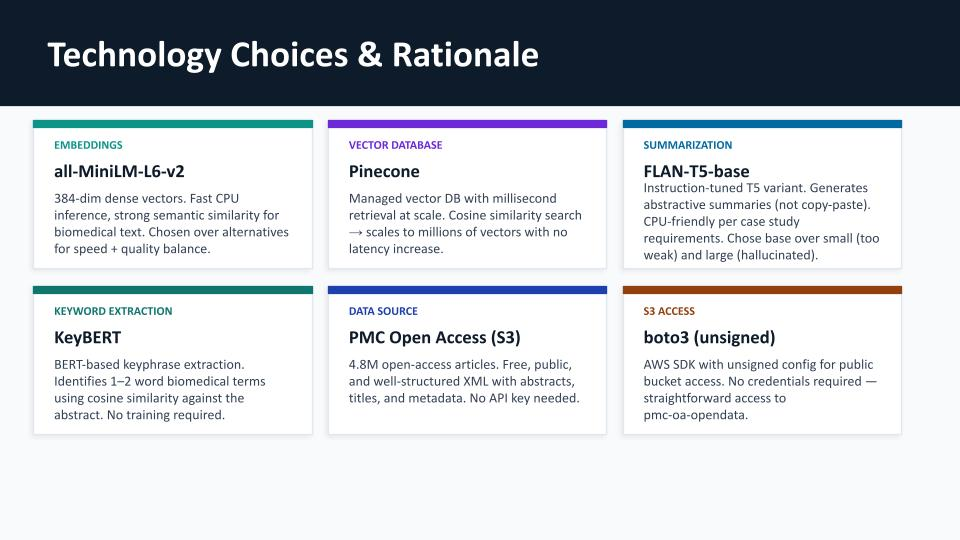

##Section 3: Summarizer Agent

In [13]:
!pip install transformers keybert torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.8 MB/s eta 0:00:00


In [14]:
import re

# Helper function to clean up output from FLAN-T5's output
def clean_summary(text: str) -> str:
    # Find the last sentence-ending punctuation
    match = re.search(r'(.*[.!?])', text, re.DOTALL)
    if match:
        return match.group(1).strip()
    return text.strip() #fallback if no punctuation found at all

In [15]:
from transformers import T5ForConditionalGeneration, T5Tokenizer
from keybert import KeyBERT
from typing import List, Dict

class SummarizerAgent:

    def __init__(self):
        # Tried BART, FLAN-T5-small, FLAN-T5-large, t5-small, all led to poor results
        # Load FLAN-T5-base — instruction-following model for summarisation
        print("Loading FLAN-T5-base...")
        self.tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-base")
        self.model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base")
        self.kw_model = KeyBERT()
        print("✓ Summarizer Agent ready")

    def summarize(self, title: str, abstract: str) -> Dict:
        # Detailed prompt — tells the model exactly what structure we want
        # "Do not invent details" reduces hallucination
        prompt = (
          "You are a biomedical research assistant.\n"
          "Summarize the following biomedical abstract in 2-3 sentences.\n"
          "Use only information explicitly stated in the abstract.\n"
          "Include: (1) study objective, (2) main result if stated, and (3) conclusion or implication if stated.\n"
          "Do not invent details. Do not use bullet points.\n\n"
          f"Abstract: {abstract}"
          )

        # Tokenize — converts text to token IDs the model understands
        inputs = self.tokenizer(
            prompt,
            return_tensors="pt",
            max_length=512,
            truncation=True  # cut off if prompt exceeds 512 tokens
        )

        # Generate summary using beam search (more reliable than random sampling)
        output_ids = self.model.generate(
            inputs["input_ids"],
            max_new_tokens=90,
            num_beams=4,                # explore 4 paths, pick the best
            do_sample=False,            # deterministic — same input = same output
            length_penalty=1.5,         # encourage longer, more complete summaries
            early_stopping=False,
            no_repeat_ngram_size=3     # prevent repetitive phrases
        )

         # Decode token IDs back to readable text
        summary = self.tokenizer.decode(output_ids[0], skip_special_tokens=True)
        summary = clean_summary(summary)

         # Extract top 5 keywords from the abstract using KeyBERT
        keywords_raw = self.kw_model.extract_keywords(
            abstract,
            keyphrase_ngram_range=(1, 2),  # single words and two-word phrases
            stop_words='english',
            top_n=5
        )
        keywords = [kw[0] for kw in keywords_raw]  # drop the scores, keep just the words

        return {'summary': summary, 'keywords': keywords}

    def summarize_batch(self, articles: List[Dict]) -> List[Dict]:
        # Run summarise on each article and add results to the article dict
        results = []
        for i, article in enumerate(articles):
            print(f"  [{i+1}/{len(articles)}] {article['title'][:60]}...")
            summary_data = self.summarize(article['title'], article['abstract'])
            enriched = article.copy()
            enriched.update(summary_data)
            results.append(enriched)
        return results


# Instantiate and test
summarizer = SummarizerAgent()

print(f"Abstract:\n{abstract[:600]}...\n")

output = summarizer.summarize(results[0]['title'], results[0]['abstract'])
print(f"Summary : {output['summary']}")
print(f"Keywords: {', '.join(output['keywords'])}")

Loading FLAN-T5-base...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Summarizer Agent ready
Abstract:
Background Invasive pancreatic neoplasms have a high propensity for recurrence even after curative resection. Recently, patients who underwent pancreatectomy have an opportunity of undergoing secondary pancreatic resection, so-called “repeat pancreatectomy” to achieve curative operation and prolong their survival. We evaluated the long-term clinical outcomes and identified the prognostic factors, including systemic inflammation markers and the lymphocyte-to-monocyte ratio (LMR) of patients who underwent repeat pancreatectomy for invasive pancreatic tumors. Methods Twenty-eight consecutive pati...

Summary : An additional heterologous or homologous COVID-19 vaccine dose for non-seroconverted immunocompromised patients was well tolerated and demonstrated comparable vaccine immunogenicity among non-SARS-CoV-2 immunocompetent patients after a two-dose primary series of mRNA vaccine.
Keywords: vaccine immunogenicity, compare immunogenicity, vaccine dose, i

##Section 4: Report Generation

In [16]:
# Rule-based study type classifier
# These terms are standard in biomedical literature — authors reliably use them
# to describe their methodology, so keyword matching works well here

CATEGORY_KEYWORDS = {
    "Clinical Trial":      ["randomized", "randomised", "clinical trial", "rct", "placebo"],
    "Review Paper":        ["systematic review", "meta-analysis", "literature review", "rapid review"],
    "Case Study":          ["case report", "case study", "case series"],
    "Computational Study": ["computational", "machine learning", "deep learning", "algorithm", "transformer"],
    "Observational Study": ["cohort", "observational", "prospective", "retrospective"],
}

def categorize_article(title: str, abstract: str) -> str:
    # Combine and lowercase for case-insensitive matching
    text = (title + " " + abstract).lower()
    # Return the first matching category
    for category, keywords in CATEGORY_KEYWORDS.items():
        if any(k in text for k in keywords):
            return category
    return "Other"   # fallback if no keywords matched

In [ ]:
import json
from datetime import datetime

# Updated pipeline — adds confidence warning on top of retrieve + summarise
def run_pipeline(query: str, top_k: int = 5) -> List[Dict]:
    print(f"Retrieving articles...")
    retrieved = retrieve(query, top_k=top_k)

    # Warn if best retrieval score is low — query may be outside the corpus
    top_score = retrieved[0]['score'] if retrieved else 0
    if top_score < 0.4:
        print(f"⚠️  Low confidence results (best score: {top_score:.4f}) — query may be outside the current knowledge base")
    else:
        print(f"✓  Retrieval confidence OK (best score: {top_score:.4f})")

    print(f"Summarizing {len(retrieved)} articles...")
    enriched = summarizer.summarize_batch(retrieved)
    return enriched

def generate_report(queries: List[str], top_k: int = 5) -> str:
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M")
    # Report header
    lines = []
    lines.append("=" * 70)
    lines.append("BIOMEDICAL LITERATURE REVIEW — AUTOMATED REPORT")
    lines.append(f"Generated: {timestamp}")
    lines.append(f"Corpus: PMC Open Access (oa_comm) | Articles indexed: 100")
    lines.append(f"Models: all-MiniLM-L6-v2 (retrieval) | FLAN-T5-base (summarization)")
    lines.append("=" * 70)

    all_results = {}

    for i, query in enumerate(queries, 1):
        lines.append(f"\nQUERY {i}: {query}")
        lines.append("-" * 70)

        results = run_pipeline(query, top_k=top_k)
        all_results[query] = results

        # Add confidence warning to report text
        top_score = results[0]['score'] if results else 0
        if top_score < 0.4:
          lines.append(f"  ⚠️  Low confidence (best score: {top_score:.4f}) — results may not be relevant")
        else:
          lines.append(f"  ✓  Confidence OK (best score: {top_score:.4f})")

        for j, article in enumerate(results, 1):
            # Categorize each article by study type
            category = categorize_article(article['title'], article['abstract'])
            lines.append(f"\n  [{j}] {article['title']}")
            lines.append(f"      Category: {category}")
            lines.append(f"      Journal : {article['journal']}")
            lines.append(f"      PMID    : {article['pmid']}")
            lines.append(f"      Score   : {article['score']:.4f}")
            lines.append(f"      Summary : {article['summary']}")
            lines.append(f"      Keywords: {', '.join(article['keywords'])}")

    lines.append("\n" + "=" * 70)
    lines.append("END OF REPORT")
    lines.append("=" * 70)

    return "\n".join(lines), all_results


# Run all 3 case study queries
queries = [
    "Adverse events with mRNA vaccines in pediatrics",
    "Transformer-based models for protein folding",
    "Clinical trial outcomes for monoclonal antibodies in oncology"
]

report_text, all_results = generate_report(queries)

# Print report
print(report_text)

# Save as text file
with open("report.txt", "w") as f:
    f.write(report_text)

# Save structured results as JSON
with open("report.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("\nReport saved to report.txt and report.json")

Retrieving articles...
✓  Retrieval confidence OK (best score: 0.5473)
Summarizing 5 articles...
  [1/5] A Comparison of the Immunogenicity and Safety of an Addition...
  [2/5] Changes in Local and Systemic Adverse Effects following Prim...


##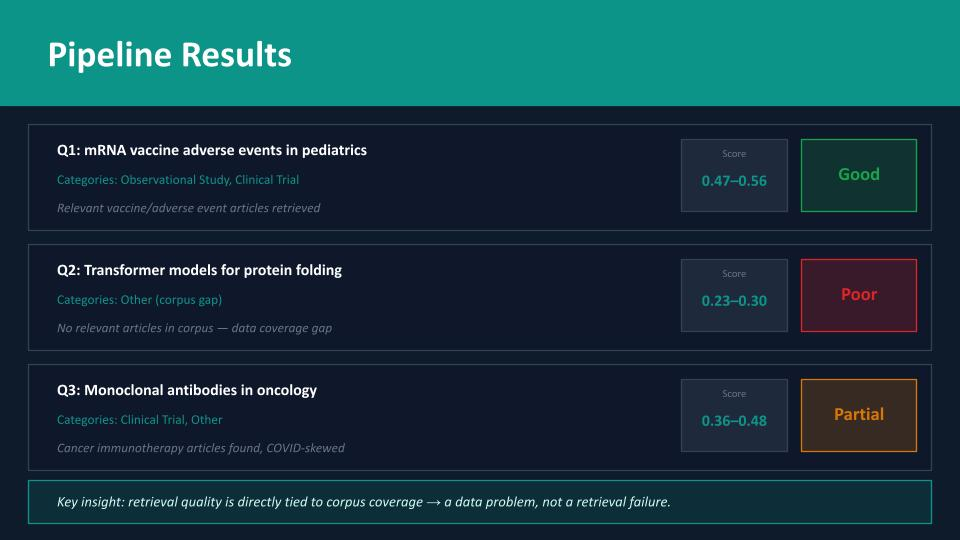

##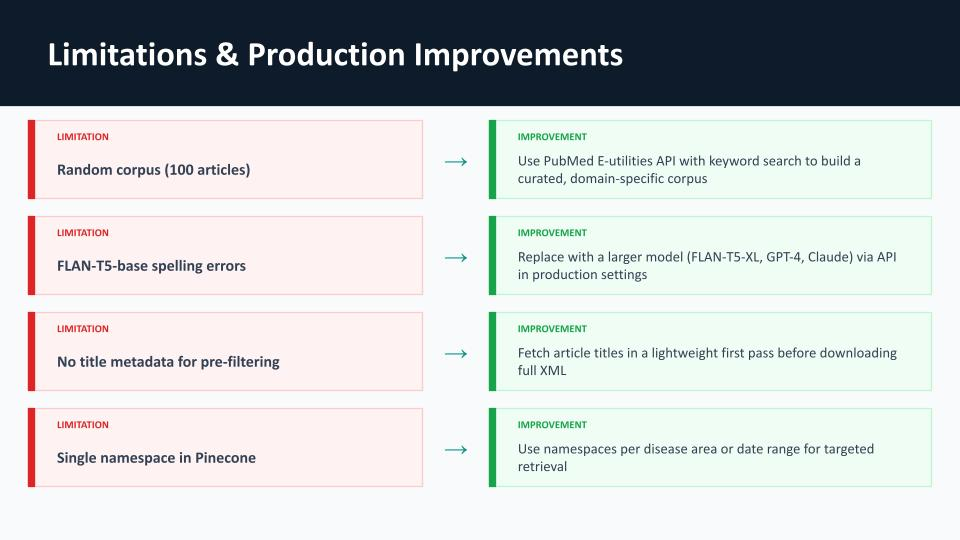

##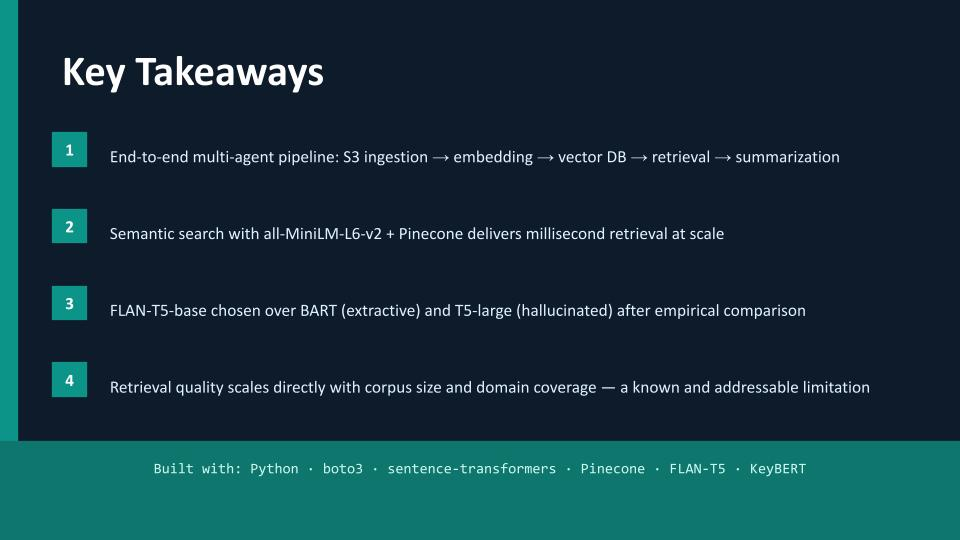